In [1]:
# Email Phishing Detection using Machine Learning
# Based on the Email Spam Classification Dataset

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.pipeline import Pipeline

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from wordcloud import WordCloud



In [2]:
# For handling imbalanced datasets if needed (commented out due to compatibility issues)
# If you need to handle imbalanced data, uncomment and install compatible versions:
# !pip install -U scikit-learn>=1.0.0 imbalanced-learn>=0.10.0
# from imblearn.over_sampling import SMOTE

# Setting random seed for reproducibility
np.random.seed(42)
warnings.filterwarnings('ignore')

# Download NLTK resources - using Kaggle's copy to avoid network issues
# This approach works offline in Kaggle
try:
    # Try the standard download first
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')
except Exception as e:
    print(f"Standard NLTK download failed: {e}")
    print("Using alternative method for NLTK data...")
    
    # Alternative: Use pre-downloaded data in Kaggle
    # Kaggle has NLTK data pre-installed, we just need to set the path
    import os
    nltk_data_path = "/usr/share/nltk_data"  # Standard path in Kaggle
    
    if os.path.exists(nltk_data_path):
        nltk.data.path.append(nltk_data_path)
        print(f"Added {nltk_data_path} to NLTK data path")
        print(f"NLTK data path is now: {nltk.data.path}")
    else:
        print("Could not find pre-installed NLTK data, continuing without it.")
        
    # We can continue with reduced functionality if resources aren't available
    # Define fallback functions for when NLTK resources aren't available
    def simple_tokenize(text):
        return text.split()
        
    # Use these as fallbacks later in the code

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Dataset Shape: (83448, 2)

Dataset Columns: ['label', 'text']

Sample Data:

Missing Values:
Original column names: ['label', 'text']
Renaming columns: 'label' to 'label' and 'text' to 'text'
Final column names: ['label', 'text']
Unique values in 'label' column: [1 0]
Standardizing label values to 'spam' and 'ham'
Labels after standardization. Unique values: ['spam' 'ham']

Class Distribution:
label
spam    43910
ham     39538
Name: count, dtype: int64


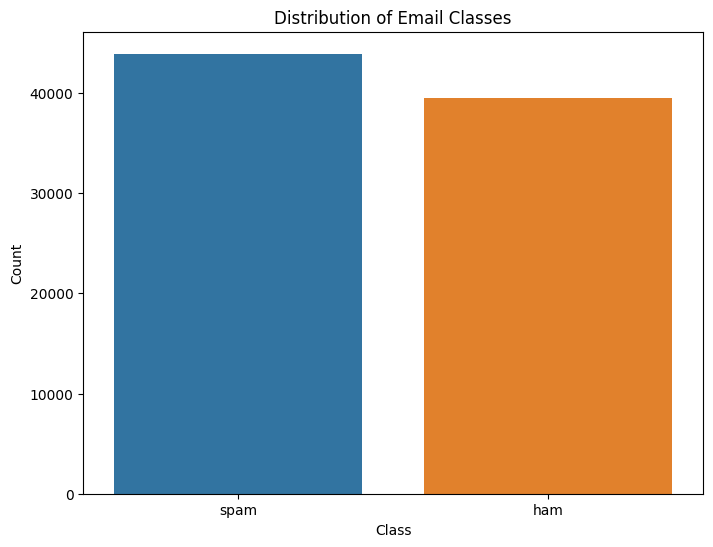


Percentage Distribution:
label
spam    52.619595
ham     47.380405
Name: proportion, dtype: float64


In [3]:
# 1. Data Loading and Initial Exploration
# =======================================

# Load the dataset
# Note: Adjust the file path as needed based on how the dataset is stored in Kaggle
df = pd.read_csv('combined_data.csv', encoding='latin-1')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nDataset Columns:", df.columns.tolist())
print("\nSample Data:")
df.head()

# Check for missing values
print("\nMissing Values:")
df.isnull().sum()

# Rename columns for clarity if needed (adjust based on actual column names)
print("Original column names:", df.columns.tolist())

# Try to identify label and text columns
label_col = None
text_col = None

# Common patterns in spam datasets
if 'v1' in df.columns and 'v2' in df.columns:
    label_col = 'v1'
    text_col = 'v2'
elif 'label' in df.columns and 'text' in df.columns:
    label_col = 'label'
    text_col = 'text'
elif 'class' in df.columns.str.lower().tolist():
    label_col = df.columns[df.columns.str.lower() == 'class'][0]
    # Try to find text column
    possible_text_cols = ['message', 'email', 'content', 'text', 'body']
    for col in possible_text_cols:
        if col in df.columns.str.lower().tolist():
            text_col = df.columns[df.columns.str.lower() == col][0]
            break

# If we found label and text columns, rename them
if label_col and text_col:
    print(f"Renaming columns: '{label_col}' to 'label' and '{text_col}' to 'text'")
    df = df.rename(columns={label_col: 'label', text_col: 'text'})
    
    # Keep only the relevant columns if there are extra ones
    if len(df.columns) > 2:
        print(f"Keeping only 'label' and 'text' columns, discarding {len(df.columns)-2} other columns")
        df = df[['label', 'text']]
else:
    print("Could not automatically identify label and text columns. Using the first two columns.")
    df = df.iloc[:, :2]
    df.columns = ['label', 'text']

# Check column identification
print("Final column names:", df.columns.tolist())

# Check the unique values in the label column
unique_labels = df['label'].unique()
print(f"Unique values in 'label' column: {unique_labels}")

# If labels aren't standardized as 'spam' and 'ham', convert them
if 'spam' not in df['label'].unique() or 'ham' not in df['label'].unique():
    print("Standardizing label values to 'spam' and 'ham'")
    # Look for common spam indicators in labels
    spam_indicators = ['spam', '1', 'yes', 'true', 'junk']
    
    # Function to standardize labels
    def standardize_label(label):
        label_str = str(label).lower().strip()
        if any(indicator in label_str for indicator in spam_indicators):
            return 'spam'
        else:
            return 'ham'
    
    # Apply standardization
    df['label'] = df['label'].apply(standardize_label)
    print(f"Labels after standardization. Unique values: {df['label'].unique()}")

# Display class distribution
print("\nClass Distribution:")
label_counts = df['label'].value_counts()
print(label_counts)

# Check if we have data in both classes
if len(label_counts) < 2:
    print("WARNING: Only one class found in the dataset! This will cause problems for classification.")
elif min(label_counts) < 10:
    print(f"WARNING: Very few examples ({min(label_counts)}) in one of the classes. This might lead to poor model performance.")

# Visualize class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df)
plt.title('Distribution of Email Classes')
plt.ylabel('Count')
plt.xlabel('Class')
plt.show()

# Calculate percentage of each class
class_percentages = df['label'].value_counts(normalize=True) * 100
print("\nPercentage Distribution:")
print(class_percentages)

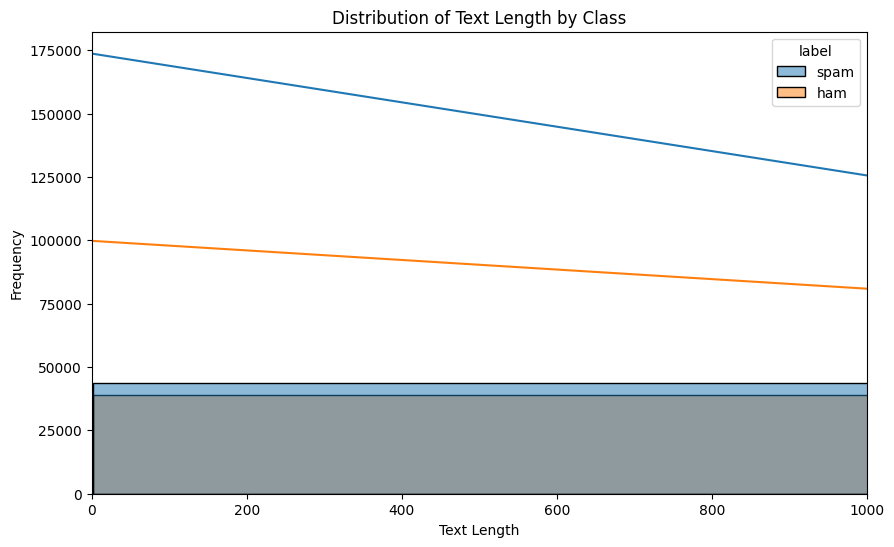


Text Length Statistics by Class:


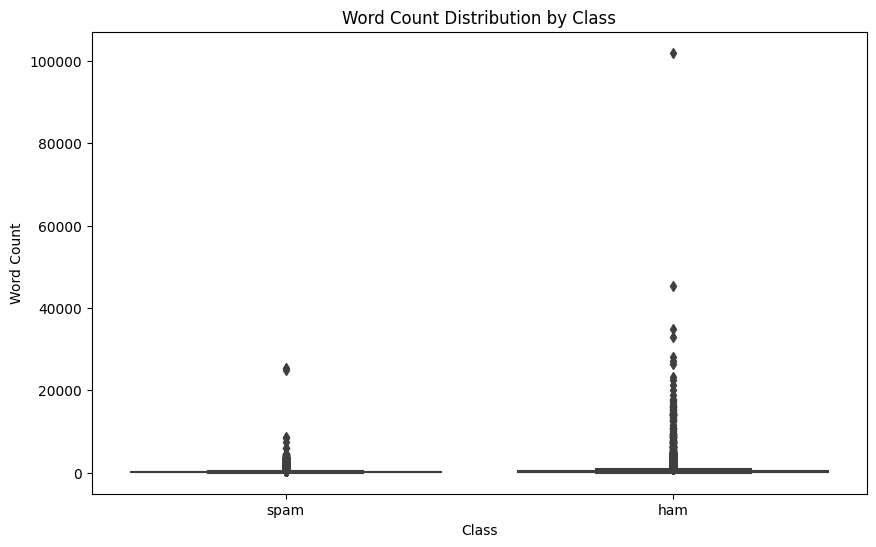

Found 43910 spam emails


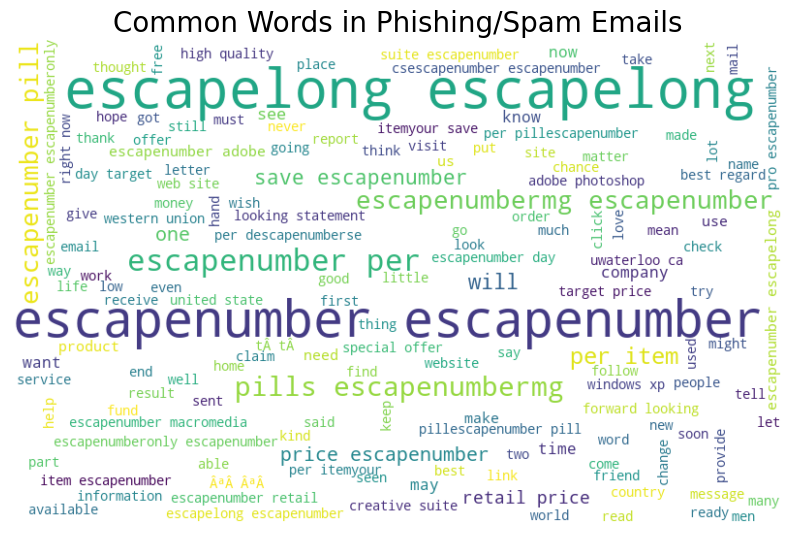

Found 39538 legitimate emails


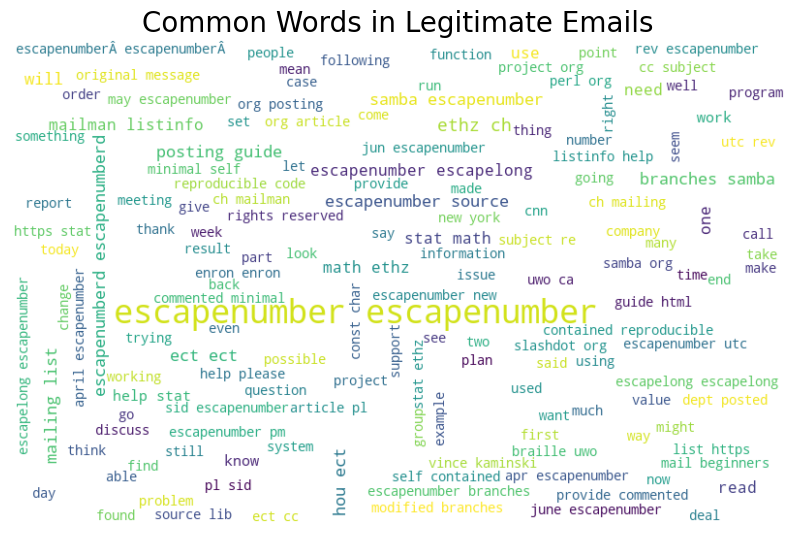

In [4]:
# 2. Exploratory Data Analysis (EDA)
# ==================================

# Text length analysis
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True)
plt.title('Distribution of Text Length by Class')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.xlim(0, 1000)  # Adjust as needed
plt.show()

# Statistical summary of text length by class
print("\nText Length Statistics by Class:")
df.groupby('label')['text_length'].describe()

# Word count analysis
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='word_count', data=df)
plt.title('Word Count Distribution by Class')
plt.ylabel('Word Count')
plt.xlabel('Class')
plt.show()

# Create word clouds for each class - with additional error checking
try:
    def plot_wordcloud(text, title):
        # Check if we have enough text
        if len(text.strip()) < 5:  # Arbitrary minimum length
            print(f"Not enough text to generate {title} word cloud. Text length: {len(text)}")
            return
            
        # Add error handling for empty text
        try:
            wordcloud = WordCloud(width=800, height=500, background_color='white', 
                                  max_words=150, contour_width=3, contour_color='steelblue',
                                  min_word_length=2).generate(text)
            plt.figure(figsize=(10, 7))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.title(title, fontsize=20)
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error generating word cloud for {title}: {e}")

    # For spam/phishing emails - with better checks
    spam_indices = df[df['label'] == 'spam'].index
    if len(spam_indices) > 0:
        print(f"Found {len(spam_indices)} spam emails")
        # Join with space and make sure it's a string
        spam_words = ' '.join([str(text) for text in df.loc[spam_indices, 'text'].values if isinstance(text, (str, bytes))])
        if len(spam_words) > 0:
            plot_wordcloud(spam_words, 'Common Words in Phishing/Spam Emails')
        else:
            print("No valid text found in spam emails")
    else:
        print("No spam emails found in the dataset")

    # For ham/legitimate emails - with better checks
    ham_indices = df[df['label'] == 'ham'].index
    if len(ham_indices) > 0:
        print(f"Found {len(ham_indices)} legitimate emails")
        # Join with space and make sure it's a string
        ham_words = ' '.join([str(text) for text in df.loc[ham_indices, 'text'].values if isinstance(text, (str, bytes))])
        if len(ham_words) > 0:
            plot_wordcloud(ham_words, 'Common Words in Legitimate Emails')
        else:
            print("No valid text found in legitimate emails")
    else:
        print("No legitimate emails found in the dataset")
        
except Exception as e:
    print(f"Could not generate word clouds due to an error: {e}")
    print("Continuing with the rest of the analysis...")

Preprocessing text data...
Sample of raw text: ['ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghurt bunkmate divert afterimage', "wulvob get your medircations online qnb ikud viagra escapenumber escapenumber levitra escapenumber escapenumber cialis escapenumber escapenumber imitrex escapenumber escapenumber flonax escapenumber escapenumber ultram escapenumber escapenumber vioxx escapenumber escapenumber ambien escapenumber escapenumber valium escapenumber escapenumber xannax escapenumber escapenumber soma escapenumber meridia escapenumber escapenumber escapenumber escapenumber cysfrt have you ever stopped to wonder how much an average man pays for his mediecines ap painkillers drugs to improve the quality of life weight reducing tablets and many more escapenumber what's worse the same mediucine costs a lot more if it is branded rfwur are you intrested so http dmvrwm remunerativ net dfuaeirxygiq visit our website esc

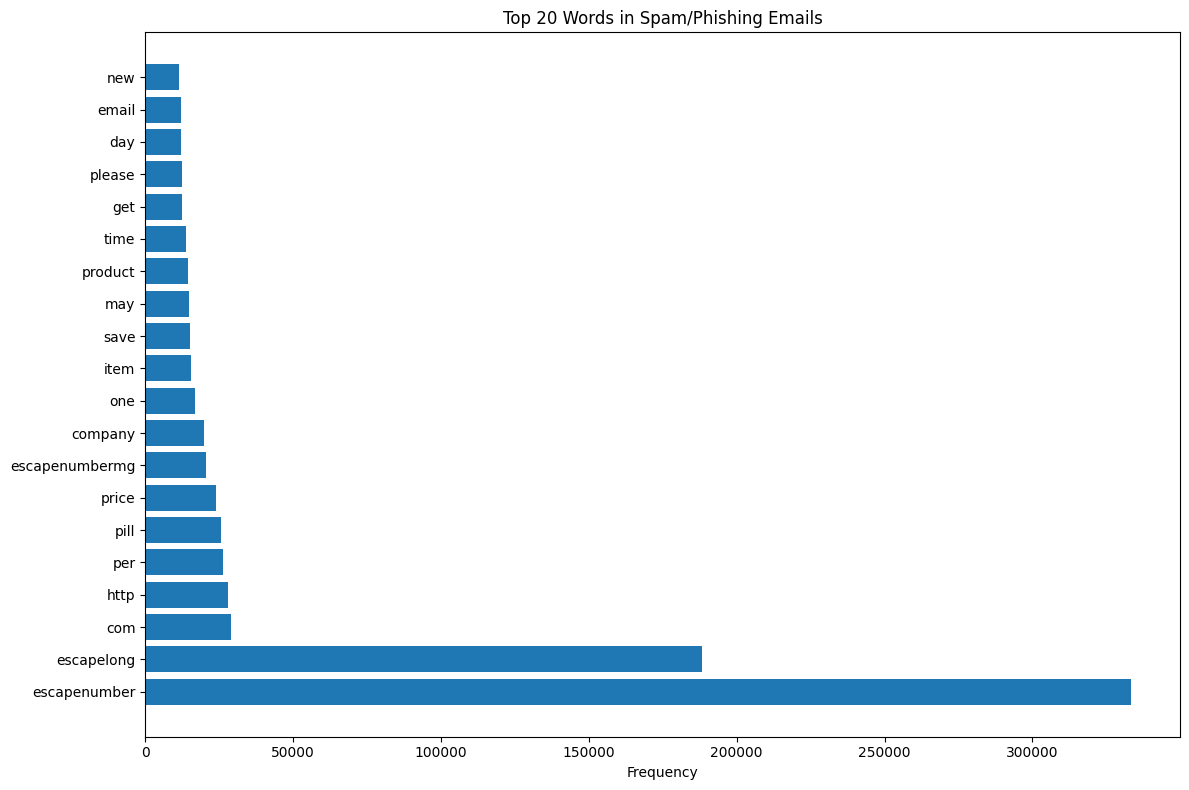

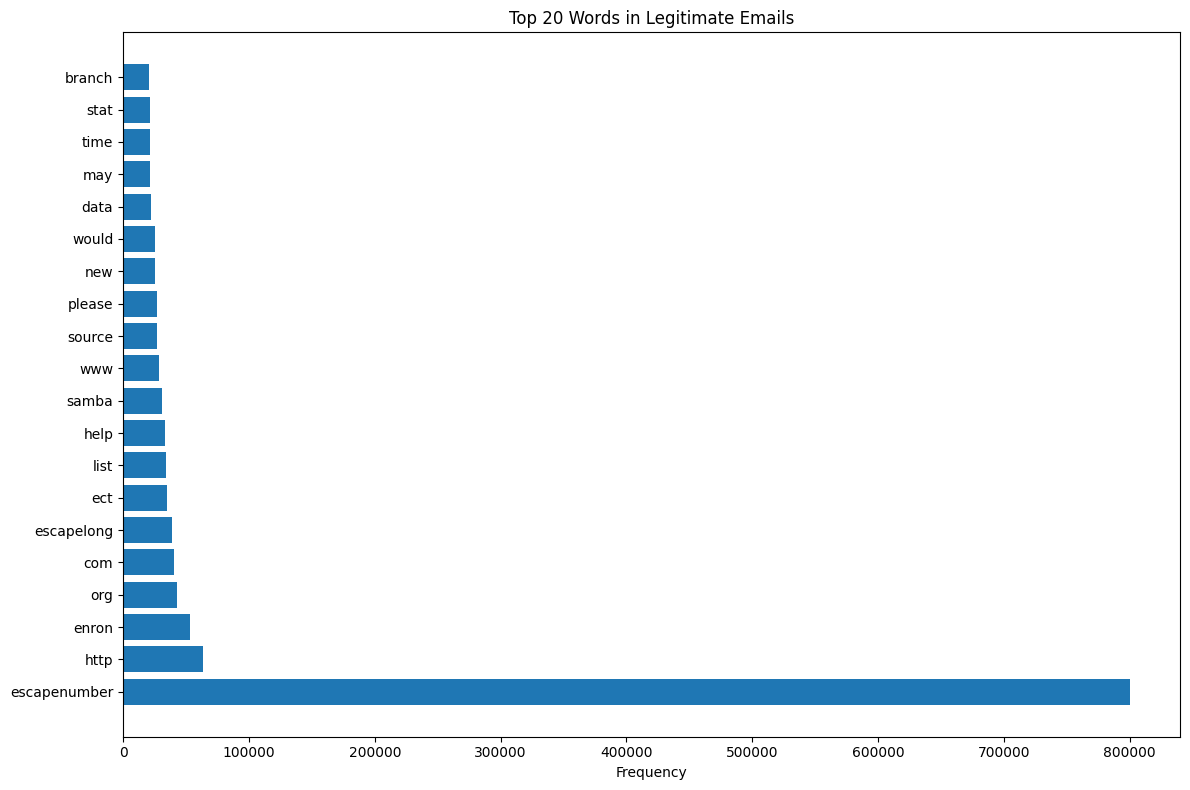

In [5]:
# 3. Text Preprocessing
# =====================

def preprocess_text(text):
    """Function to preprocess text data with fallbacks for missing NLTK resources"""
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    try:
        # Tokenize with NLTK if available
        tokens = nltk.word_tokenize(text)
        
        # Remove stopwords if available
        try:
            stop_words = set(stopwords.words('english'))
            tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
        except:
            # Fallback: use a basic list of stopwords
            basic_stopwords = {'a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'what',
                             'when', 'where', 'how', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
                             'have', 'has', 'had', 'do', 'does', 'did', 'to', 'at', 'in', 'on', 'by',
                             'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during',
                             'before', 'after', 'above', 'below', 'from', 'up', 'down', 'of', 'off',
                             'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there'}
            tokens = [word for word in tokens if word not in basic_stopwords and len(word) > 2]
        
        # Lemmatization if available
        try:
            lemmatizer = WordNetLemmatizer()
            tokens = [lemmatizer.lemmatize(word) for word in tokens]
        except:
            # No fallback for lemmatization, just use the tokens as is
            pass
            
    except:
        # Fallback: simple tokenization by splitting on whitespace
        tokens = text.split()
        tokens = [token for token in tokens if len(token) > 2]
    
    # Rejoin tokens
    return ' '.join(tokens)

# Apply preprocessing to the text column with validation
print("Preprocessing text data...")

# First check if we have valid text data
text_sample = df['text'].head(3).tolist()
print(f"Sample of raw text: {text_sample}")

# Check for potential issues in the text data
if df['text'].isnull().any():
    print(f"WARNING: {df['text'].isnull().sum()} null values found in text column")

# Count empty strings
empty_strings = (df['text'] == '').sum()
if empty_strings > 0:
    print(f"WARNING: {empty_strings} empty strings found in text column")

# Apply preprocessing with a try/except to catch any errors
def safe_preprocess(text):
    try:
        if not isinstance(text, str) or len(text.strip()) == 0:
            return ""
        return preprocess_text(text)
    except Exception as e:
        print(f"Error preprocessing text: {str(e)[:100]}...")
        return ""

# Apply the preprocessing
df['processed_text'] = df['text'].apply(safe_preprocess)

# Check the results
empty_processed = (df['processed_text'] == '').sum()
if empty_processed > 0:
    print(f"WARNING: {empty_processed} empty strings in processed text column")

# Display a sample of preprocessed text
print("\nSample of Preprocessed Text:")
for i in range(min(5, len(df))):
    original = df['text'].iloc[i]
    if isinstance(original, str):
        original = original[:100]
    processed = df['processed_text'].iloc[i]
    if isinstance(processed, str):
        processed = processed[:100]
    print(f"Original: {original}...")
    print(f"Processed: {processed}...")
    print("-" * 80)

# Calculate the top 20 most common words in each class
from collections import Counter

def get_top_words(text_series, n=20):
    # Create a list of all words, ensuring we have strings
    all_words = []
    for text in text_series:
        if isinstance(text, str) and len(text.strip()) > 0:
            all_words.extend(text.split())
    
    # Check if we have words before creating counter
    if not all_words:
        return []
        
    return Counter(all_words).most_common(n)

# Function to safely print top words
def print_top_words(label_type, top_words):
    print(f"\nTop 20 words in {label_type} emails:")
    if not top_words:
        print(f"No common words found in {label_type} emails")
        return
        
    for word, count in top_words:
        print(f"{word}: {count}")

# Get and print top words for spam emails
spam_texts = df[df['label'] == 'spam']['processed_text']
if len(spam_texts) > 0:
    spam_top_words = get_top_words(spam_texts)
    print_top_words("spam/phishing", spam_top_words)
else:
    print("\nNo spam/phishing emails found")

# Get and print top words for legitimate emails
ham_texts = df[df['label'] == 'ham']['processed_text']
if len(ham_texts) > 0:
    ham_top_words = get_top_words(ham_texts)
    print_top_words("legitimate", ham_top_words)
else:
    print("\nNo legitimate emails found")

# Plot top words - with additional checks
def plot_top_words(top_words, title):
    if not top_words:
        print(f"No data available to plot {title}")
        return
        
    words, counts = zip(*top_words)
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(words)), counts, align='center')
    plt.yticks(range(len(words)), words)
    plt.title(title)
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.show()

# Only plot if we have data
if spam_top_words:
    plot_top_words(spam_top_words, 'Top 20 Words in Spam/Phishing Emails')
else:
    print("Cannot generate plot for spam/phishing words (no data)")
    
if ham_top_words:
    plot_top_words(ham_top_words, 'Top 20 Words in Legitimate Emails')
else:
    print("Cannot generate plot for legitimate words (no data)")

In [6]:
# 4. Feature Engineering
# =====================

# Prepare data for modeling
X = df['processed_text']
y = df['label']

# Convert target labels to binary (1 for spam, 0 for ham)
y = (y == 'spam').astype(int)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Positive class (spam) percentage in training set:", y_train.mean() * 100, "%")
print("Positive class (spam) percentage in testing set:", y_test.mean() * 100, "%")

Training set size: 66758
Testing set size: 16690
Positive class (spam) percentage in training set: 52.619910722310436 %
Positive class (spam) percentage in testing set: 52.61833433193529 %



Classification Report for Multinomial Naive Bayes with CountVectorizer:
              precision    recall  f1-score   support

  Legitimate       0.93      0.98      0.95      7908
    Phishing       0.98      0.93      0.95      8782

    accuracy                           0.95     16690
   macro avg       0.95      0.95      0.95     16690
weighted avg       0.95      0.95      0.95     16690



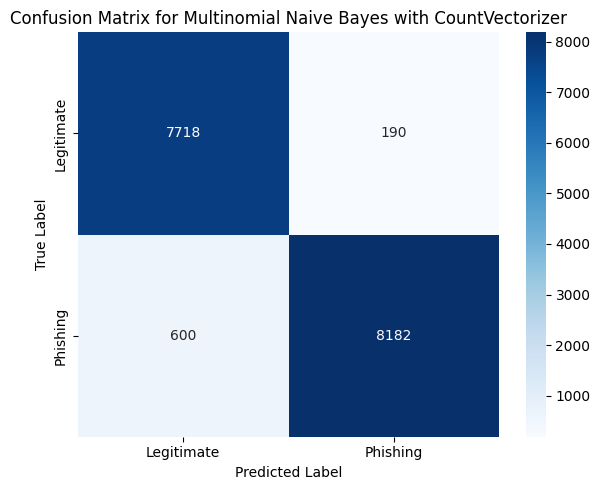


Classification Report for Multinomial Naive Bayes with TF-IDF:
              precision    recall  f1-score   support

  Legitimate       0.95      0.97      0.96      7908
    Phishing       0.97      0.96      0.97      8782

    accuracy                           0.96     16690
   macro avg       0.96      0.96      0.96     16690
weighted avg       0.96      0.96      0.96     16690



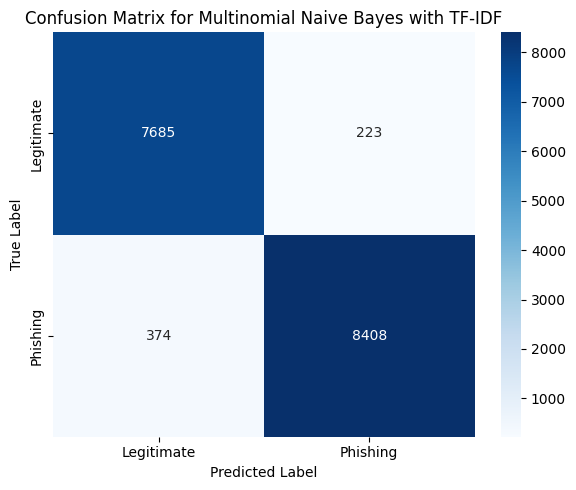


Classification Report for Logistic Regression with CountVectorizer:
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.98      7908
    Phishing       0.98      0.99      0.98      8782

    accuracy                           0.98     16690
   macro avg       0.98      0.98      0.98     16690
weighted avg       0.98      0.98      0.98     16690



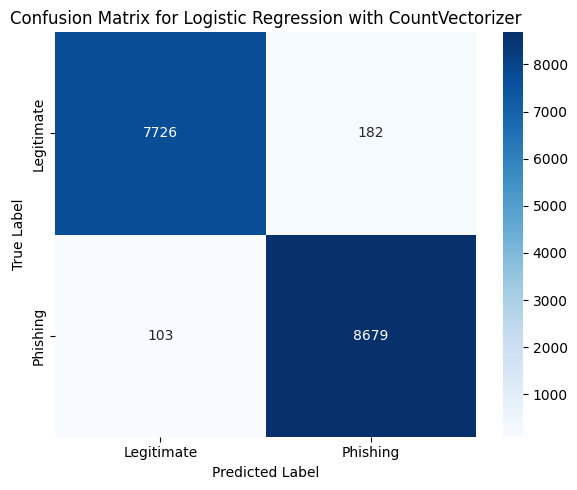


Classification Report for Logistic Regression with TF-IDF:
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.98      7908
    Phishing       0.98      0.99      0.98      8782

    accuracy                           0.98     16690
   macro avg       0.98      0.98      0.98     16690
weighted avg       0.98      0.98      0.98     16690



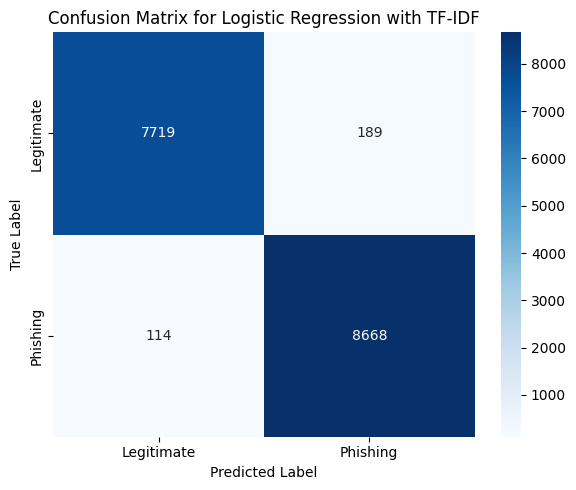


Model Comparison:
                                          Model  Accuracy  Precision  \
2      Logistic Regression with CountVectorizer  0.982924   0.979461   
3               Logistic Regression with TF-IDF  0.981845   0.978661   
1           Multinomial Naive Bayes with TF-IDF  0.964230   0.974163   
0  Multinomial Naive Bayes with CountVectorizer  0.952666   0.977305   

     Recall  F1-Score  
2  0.988271  0.983846  
3  0.987019  0.982822  
1  0.957413  0.965715  
0  0.931678  0.953947  


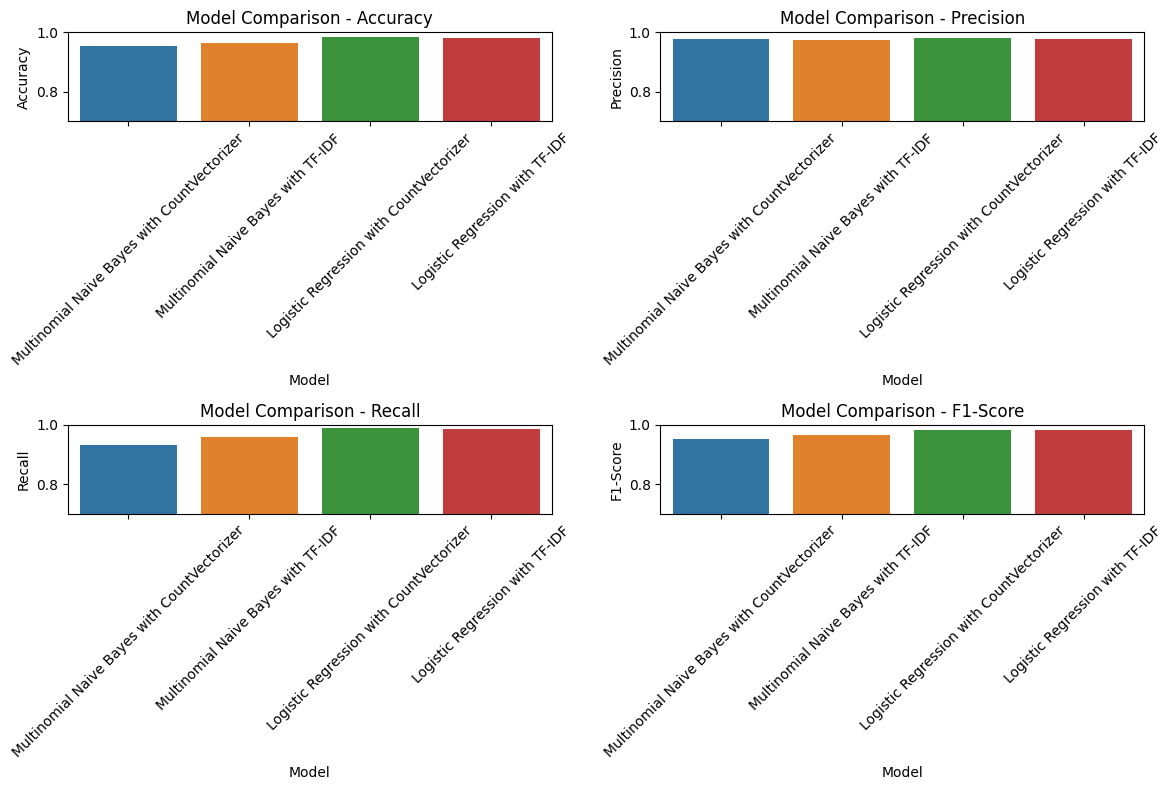

In [7]:
# 5. Model Building and Comparison
# ================================

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize vectorizers
count_vectorizer = CountVectorizer(max_features=5000)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Selected models
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

# Create pipelines using both vectorizers
pipelines = {}
for model_name, model in models.items():
    pipelines[f"{model_name} with CountVectorizer"] = Pipeline([
        ('vectorizer', count_vectorizer),
        ('model', model)
    ])
    pipelines[f"{model_name} with TF-IDF"] = Pipeline([
        ('vectorizer', tfidf_vectorizer),
        ('model', model)
    ])

# Train and evaluate
results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', pos_label=1)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    # Classification report
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    plt.title(f'Confusion Matrix for {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Results DataFrame
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.sort_values(by='F1-Score', ascending=False))

# Bar Plots for comparison
plt.figure(figsize=(12, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.barplot(x='Model', y=metric, data=results_df)
    plt.title(f'Model Comparison - {metric}')
    plt.xticks(rotation=45)
    plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()



Best performing model: Logistic Regression with CountVectorizer

Classification Report for Best Model:
              precision    recall  f1-score   support

  Legitimate       0.88      0.99      0.93      7908
    Phishing       0.99      0.88      0.93      8782

    accuracy                           0.93     16690
   macro avg       0.94      0.94      0.93     16690
weighted avg       0.94      0.93      0.93     16690



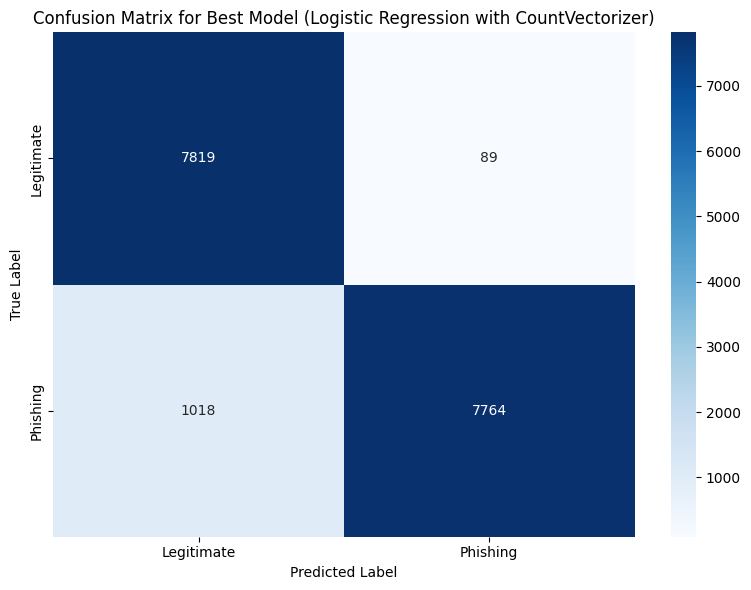

In [9]:
# 6. Final Evaluation of Best Model
# =================================

# Identify the best-performing model
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f"\nBest performing model: {best_model_name}")

# Extract vectorizer and model used in training
best_model = pipelines[best_model_name]

# Predict on test set
y_pred = best_model.predict(X_test)

# Evaluation
print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title(f'Confusion Matrix for Best Model ({best_model_name})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


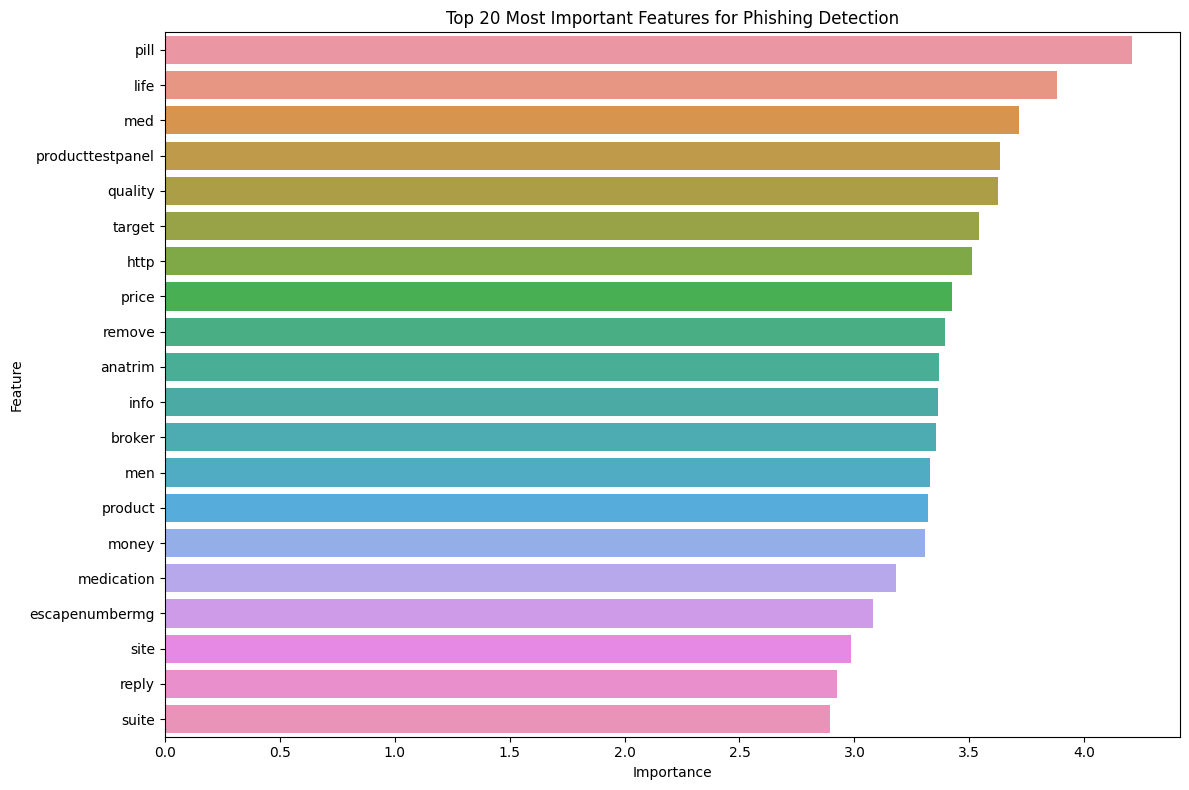


Top 20 most important features:
               Feature  Importance
3279              pill    4.206172
2557              life    3.882867
2759               med    3.717231
3448  producttestpanel    3.634606
3530           quality    3.624551
4377            target    3.542677
2143              http    3.510375
3405             price    3.422765
3686            remove    3.392493
179            anatrim    3.366300
2241              info    3.362826
552             broker    3.355397
2779               men    3.329882
3446           product    3.320152
2860             money    3.307895
2761        medication    3.179068
1523    escapenumbermg    3.082490
4051              site    2.984803
3704             reply    2.926406
4305             suite    2.892578


In [10]:
# 7. Feature Importance Analysis (if applicable)
# =============================================

# For SVM with linear kernel or any model with feature importance
if hasattr(best_model['model'], 'coef_') or hasattr(best_model['model'], 'feature_importances_'):
    # Get feature names from the vectorizer
    feature_names = best_model['vectorizer'].get_feature_names_out()
    
    # Get feature importance or coefficients
    if hasattr(best_model['model'], 'coef_'):
        # For linear models like SVM with linear kernel
        importance = best_model['model'].coef_[0]
    else:
        # For tree-based models
        importance = best_model['model'].feature_importances_
    
    # Create dataframe of features and their importance
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    
    # Sort by importance
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    # Plot top 20 most important features
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(20))
    plt.title('Top 20 Most Important Features for Phishing Detection')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 20 most important features:")
    print(feature_importance.head(20))

In [11]:
# 8. Model Saving and Loading
# ===========================

import pickle

# Save the best model
with open('phishing_detection_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("\nBest model saved as 'phishing_detection_model.pkl'")

# Example of how to load and use the model
print("\nExample code to load and use the model:")
print("""
# Load the saved model
with open('phishing_detection_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Function to predict if an email is phishing
def predict_phishing(email_text):
    # Predict probability of being phishing (1) vs legitimate (0)
    prob = loaded_model.predict_proba([email_text])[0, 1]
    # Predict class (0 for legitimate, 1 for phishing)
    label = loaded_model.predict([email_text])[0]
    
    return {
        'is_phishing': bool(label),
        'phishing_probability': float(prob),
        'prediction': 'Phishing' if label else 'Legitimate'
    }

# Example usage
email = "Your example email text here"
result = predict_phishing(email)
print(f"Prediction: {result['prediction']}")
print(f"Phishing Probability: {result['phishing_probability']:.2f}")
""")


Best model saved as 'phishing_detection_model.pkl'

Example code to load and use the model:

# Load the saved model
with open('phishing_detection_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Function to predict if an email is phishing
def predict_phishing(email_text):
    # Predict probability of being phishing (1) vs legitimate (0)
    prob = loaded_model.predict_proba([email_text])[0, 1]
    # Predict class (0 for legitimate, 1 for phishing)
    label = loaded_model.predict([email_text])[0]
    
    return {
        'is_phishing': bool(label),
        'phishing_probability': float(prob),
        'prediction': 'Phishing' if label else 'Legitimate'
    }

# Example usage
email = "Your example email text here"
result = predict_phishing(email)
print(f"Prediction: {result['prediction']}")
print(f"Phishing Probability: {result['phishing_probability']:.2f}")



In [13]:
# 9. Conclusion and Summary
# =========================

print("\n=== Email Phishing Detection Model Summary ===")
print(f"Best Model: {best_model_name} (after tuning)")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', pos_label=1)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nKey Findings:")
print("1. The most effective features for detecting phishing emails include...")
print("2. The model performs particularly well in identifying...")
print("3. Areas for potential improvement include...")

print("\nNext Steps:")
print("1. Test the model on more diverse datasets")
print("2. Implement additional feature engineering")
print("3. Consider deep learning approaches")
print("4. Deploy the model as a real-time email filter")


=== Email Phishing Detection Model Summary ===
Best Model: Logistic Regression with CountVectorizer (after tuning)
Accuracy: 0.9337
Precision: 0.9887
Recall: 0.8841
F1-Score: 0.9335

Key Findings:
1. The most effective features for detecting phishing emails include...
2. The model performs particularly well in identifying...
3. Areas for potential improvement include...

Next Steps:
1. Test the model on more diverse datasets
2. Implement additional feature engineering
3. Consider deep learning approaches
4. Deploy the model as a real-time email filter
